Leptonic equilibrium
====================

In [1]:
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pylab as plt
import jetset

In [2]:
print('tested with',jetset.__version__)

tested with 1.4.0rc3


In [139]:
import numpy as np

def pl_fit(jet_obj,x_eq):
    """ helper function to make a pl fit of the emitters above and below the cooling break.
    The function will try to avoid the cut-off close to gmax
    """
    msk=jet_obj.emitters_distribution.n_gamma_e>0
    
    msk2=np.logical_and(msk,jet_obj.emitters_distribution.gamma_e>x_eq*1.5)
    cut_off=max(jet_obj.parameters.gmax.val/2, x_eq*2)
    msk2=np.logical_and(msk2,jet_obj.emitters_distribution.gamma_e<cut_off)
    
    low_cut_off=min(jet_obj.parameters.gmin.val*2,x_eq*.5)
    msk1=np.logical_and(msk,jet_obj.emitters_distribution.gamma_e<=x_eq*.5)
    msk1=np.logical_and(msk1,jet_obj.emitters_distribution.gamma_e>low_cut_off)
    plt.figure()
    x = np.log10(jet_obj.emitters_distribution.gamma_e[msk])
    y = np.log10(jet_obj.emitters_distribution.n_gamma_e[msk])
    plt.plot(x, y)
    for m in [msk1,msk2]:
        x = np.log10(jet_obj.emitters_distribution.gamma_e[m])
        y = np.log10(jet_obj.emitters_distribution.n_gamma_e[m])

        (m,q), cov = np.polyfit(x, y, 1, cov=True)
        y_fit = m * x + q

        
        
        plt.plot(x, y_fit, label=f'spectral slope={m:.3g}')
       
        plt.tight_layout()
    plt.axvline(np.log10(x_eq),ls='--',label='eq.')
    plt.xlabel('log(n(gamma))')
    plt.ylabel('log(gamma)')
    plt.legend()
    plt.show()
    

## Setting up the model (SSC)

In [140]:
from jetset.jet_model import Jet
from jetset.jet_emitters_factory import InjEmittersFactory

q_inj = InjEmittersFactory().create_inj_emitters('pl')

my_jet=Jet(emitters_distribution=q_inj)
my_jet.parameters.p.val=2.2
my_jet.parameters.z_cosm.val=3.080000e-02
my_jet.parameters.R.val=1E16
my_jet.parameters.B.val=.1
my_jet.parameters.L_inj.val=5E38
my_jet.parameters.gmin.val=1
my_jet.parameters.gmax.val=1E6

my_jet.parameters.beam_obj.val=25
my_jet.eval()

The model inherits as parameters the parameters of the injected emitters. 

Of course, when creating the `q_inj` object you can use the same approach used for `emitters`, the only difference is that in place of the emitters density `N` you will pas the injected luminosity `L_inj`. **Moreover, the parameter  `T_esc_e_primaries`,  in units of `R/c`, will drive the equilibrium energy**.

In [142]:
my_jet.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,R,region_size,cm,1.000000e+16,1.000000e+03,1.000000e+30,False,False
jet_leptonic,R_H,region_position,cm,1.000000e+17,0.000000e+00,--,False,True
jet_leptonic,B,magnetic_field,gauss,1.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,1.000000e+06,1.000000e+00,1.000000e+15,False,False
jet_leptonic,p,LE_spectral_slope,,2.200000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,False


None

In [143]:
my_jet.eval()
my_jet.energetic_report()

name,type,units,val
BulkLorentzFactor,jet-bulk-factor,,2.500000e+01
U_e,Energy dens. blob rest. frame,erg / cm3,3.867883e-05
U_p_cold,Energy dens. blob rest. frame,erg / cm3,1.503276e-01
U_B,Energy dens. blob rest. frame,erg / cm3,3.978874e-04
U_Synch,Energy dens. blob rest. frame,erg / cm3,3.526653e-07
U_Synch_DRF,Energy dens. disk rest. frame,erg / cm3,1.377599e-01
U_Disk,Energy dens. blob rest. frame,erg / cm3,0.000000e+00
U_BLR,Energy dens. blob rest. frame,erg / cm3,0.000000e+00
U_DT,Energy dens. blob rest. frame,erg / cm3,0.000000e+00
U_Corona,Energy dens. blob rest. frame,erg / cm3,0.000000e+00


As in the case of standard jet model, we can rescale ``L_inj`` according to the desired energy density of the emitters

In [144]:
print(my_jet.parameters.L_inj.val)
my_jet.set_N_from_U_emitters(1E-3)
my_jet.eval()
print(my_jet.parameters.L_inj.val)


5e+38
1.2909340142694534e+40


Or according to the desired energy density of the emitters


1.2909340142694534e+40
1.6562574911261575e+40


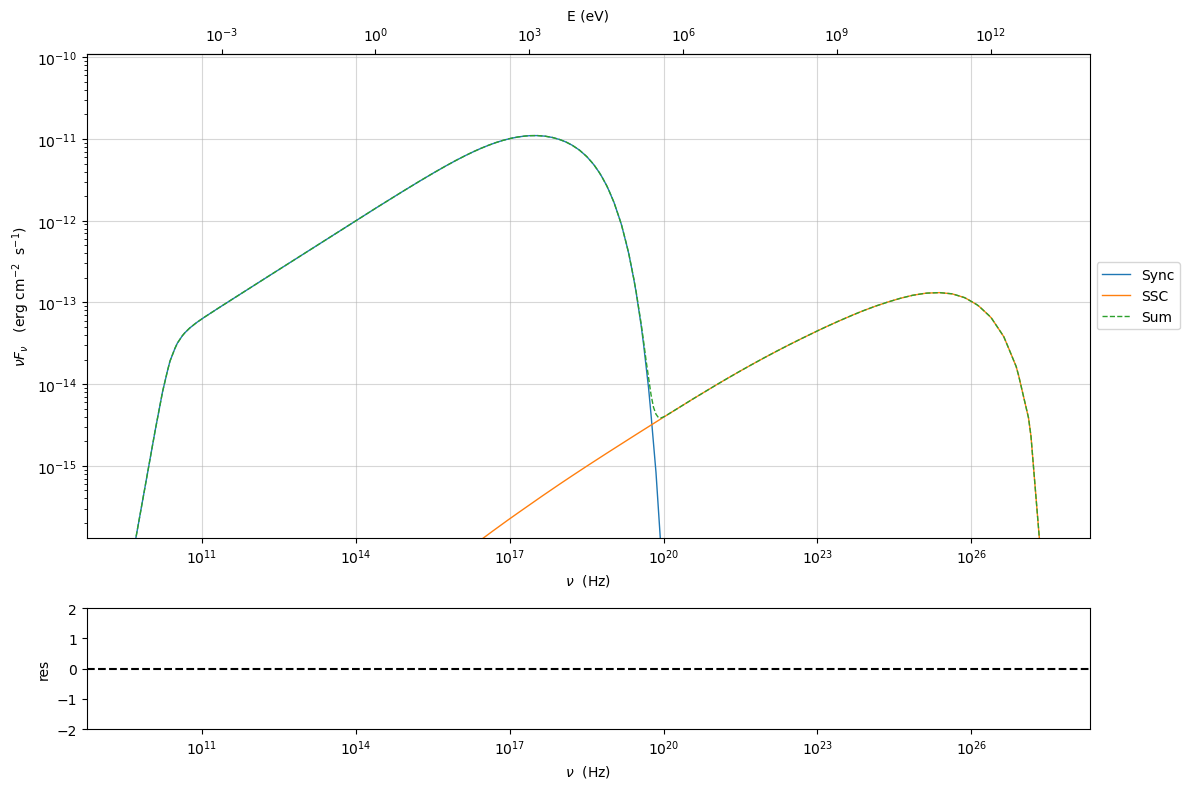

In [145]:
print(my_jet.parameters.L_inj.val)
my_jet.set_N_from_nuFnu(nu_obs=1E14,nuFnu_obs=1E-12)
my_jet.eval()
print(my_jet.parameters.L_inj.val)
my_jet.plot_model()


You can easily plot both the injected distribution and the equilibrium one

231979.40174924445


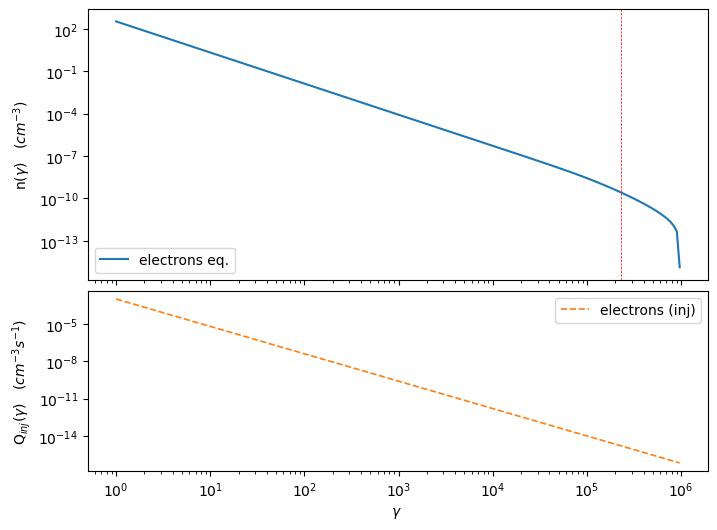

In [146]:
my_jet.eval()
my_jet.emitters_distribution.plot()
print(my_jet.emitters_distribution.gamma_cooling_eq)


In [147]:
my_jet.emitters_distribution.gamma_e.min(),my_jet.emitters_distribution.gamma_e_inj.min()

(np.float64(1.0), np.float64(1.0))

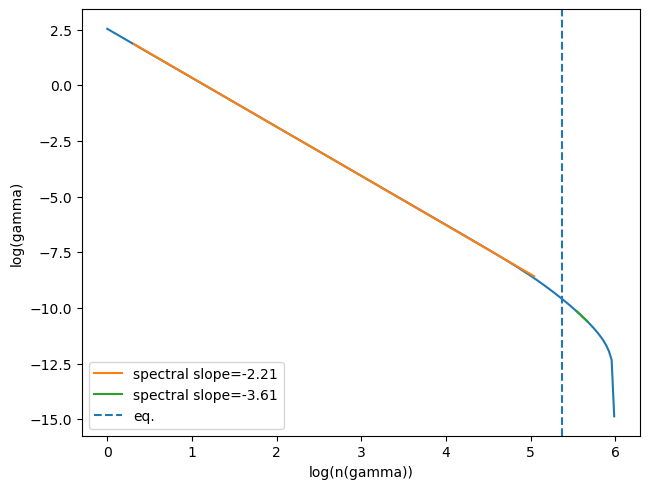

In [149]:
pl_fit(my_jet,x_eq=my_jet.emitters_distribution.gamma_cooling_eq)

9279.17606996978


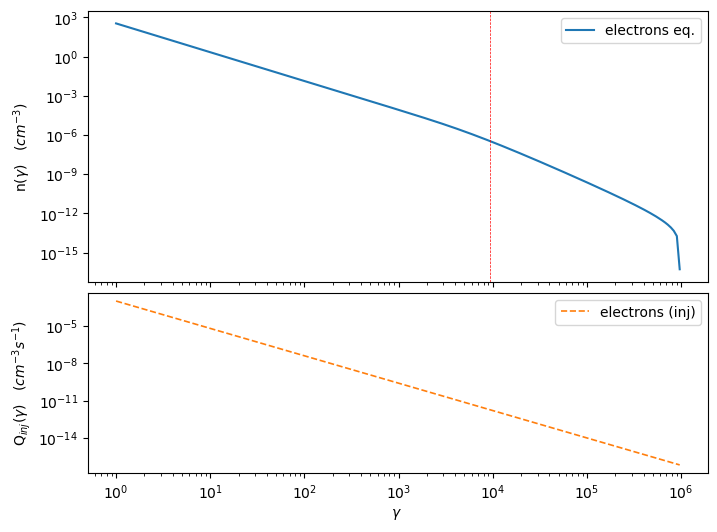

In [150]:
my_jet.parameters.B.val=.5
my_jet.eval()
my_jet.emitters_distribution.plot()
print(my_jet.emitters_distribution.gamma_cooling_eq)


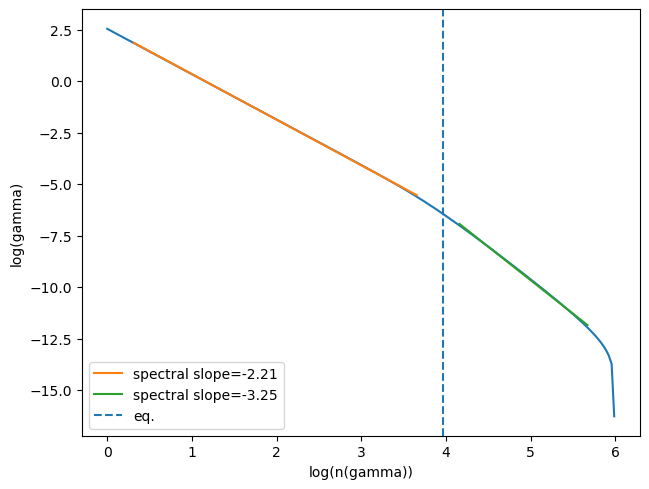

In [153]:
pl_fit(my_jet,x_eq=my_jet.emitters_distribution.gamma_cooling_eq)

The SED at the equilibrium:

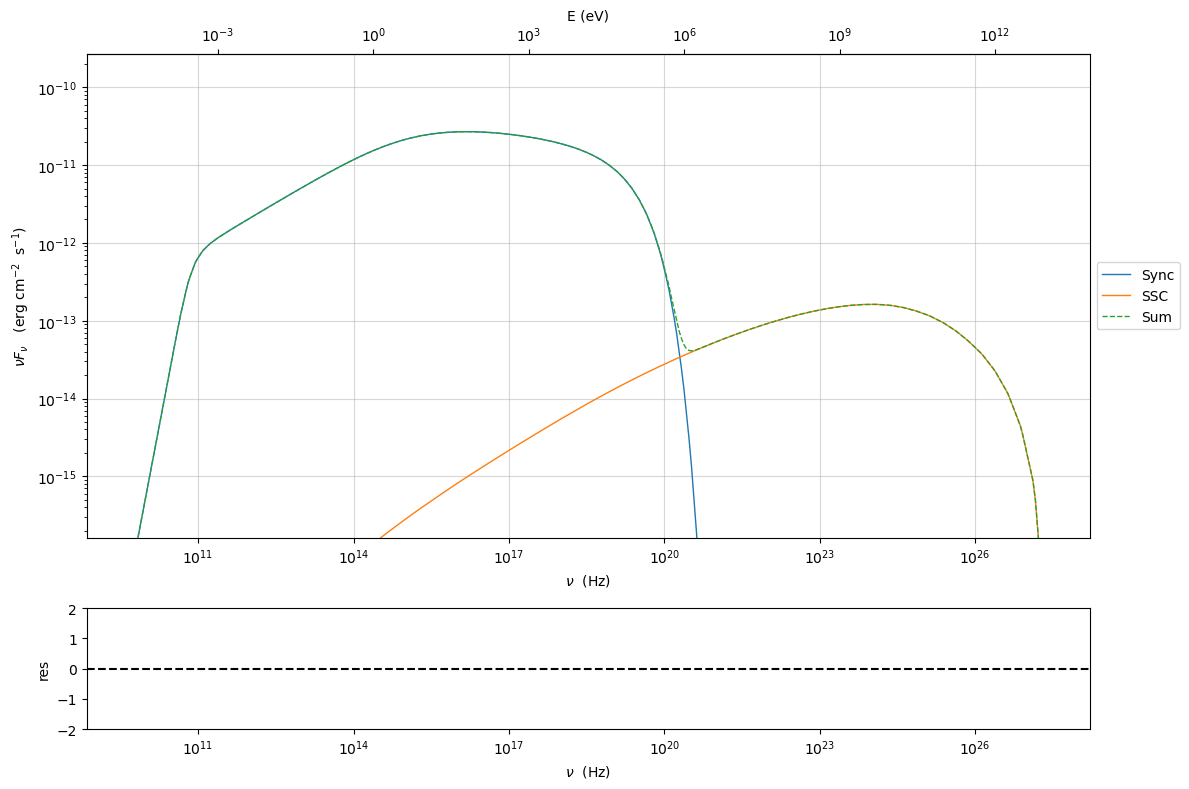

In [154]:
my_jet.eval()
my_jet.plot_model()

### Computational speed

In [122]:
%timeit my_jet.eval()


11 ms ± 246 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [123]:
j=Jet()

%timeit j.eval()


1.5 ms ± 25.7 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


The overhead time for equilibrium computation, compared to a standard leptonic model, is of a factor ~ 5, but still capable of ~ 100 evaluation per second (Apple Silicon M4 pro with C threads).

## Setting up the model (EC)

In [155]:
from jetset.jet_model import Jet
from jetset.jet_emitters_factory import InjEmittersFactory

q_inj = InjEmittersFactory().create_inj_emitters('pl')

my_jet=Jet(emitters_distribution=q_inj)
my_jet.parameters.p.val=2.2
my_jet.parameters.z_cosm.val=3.080000e-02
my_jet.parameters.B.val=.3
my_jet.parameters.p.val=2.3

my_jet.parameters.L_inj.val=1E40
my_jet.parameters.gmin.val=1
my_jet.parameters.gmax.val=3E4

my_jet.parameters.beam_obj.val=25


In [156]:
my_jet.add_EC_component(['EC_DT','EC_BLR'],disk_type='MultiBB')
my_jet.set_EC_dependencies()
my_jet.make_conical_jet()
my_jet.parameters.R_H.val=1E18

adding par: L_Disk to  R_BLR_in
==> par R_BLR_in is depending on ['L_Disk'] according to expr:   R_BLR_in =
3E17*(L_Disk/1E46)**0.5
adding par: R_BLR_in to  R_BLR_out
==> par R_BLR_out is depending on ['R_BLR_in'] according to expr:   R_BLR_out =
R_BLR_in*1.1
adding par: L_Disk to  R_DT
==> par R_DT is depending on ['L_Disk'] according to expr:   R_DT =
2E19*(L_Disk/1E46)**0.5
adding par: R_H to  R
adding par: theta_open to  R
==> par R is depending on ['R_H', 'theta_open'] according to expr:   R =
np.tan(np.radians(theta_open))*R_H
setting R_H to 5.715026151380672e+16


In [157]:
my_jet.parameters

model name,name,par type,units,val,phys. bound. min,phys. bound. max,log,frozen
jet_leptonic,"*R(D,theta_open)",region_size,cm,8.748866e+16,1.000000e+03,1.000000e+30,False,True
jet_leptonic,R_H(M),region_position,cm,1.000000e+18,0.000000e+00,--,False,False
jet_leptonic,B,magnetic_field,gauss,3.000000e-01,0.000000e+00,--,False,False
jet_leptonic,NH_cold_to_rel_e,cold_p_to_rel_e_ratio,,1.000000e+00,0.000000e+00,--,False,True
jet_leptonic,beam_obj,beaming,,2.500000e+01,1.000000e-04,--,False,False
jet_leptonic,z_cosm,redshift,,3.080000e-02,0.000000e+00,--,False,False
jet_leptonic,gmin,low-energy-cut-off,lorentz-factor*,1.000000e+00,1.000000e+00,1.000000e+09,False,False
jet_leptonic,gmax,high-energy-cut-off,lorentz-factor*,3.000000e+04,1.000000e+00,1.000000e+15,False,False
jet_leptonic,p,LE_spectral_slope,,2.300000e+00,-1.000000e+01,1.000000e+01,False,False
jet_leptonic,T_esc_e_primaries,escape_time,R / c,1.000000e+00,1.000000e+00,--,False,False


None

gamma eq. : 869.8102277115541


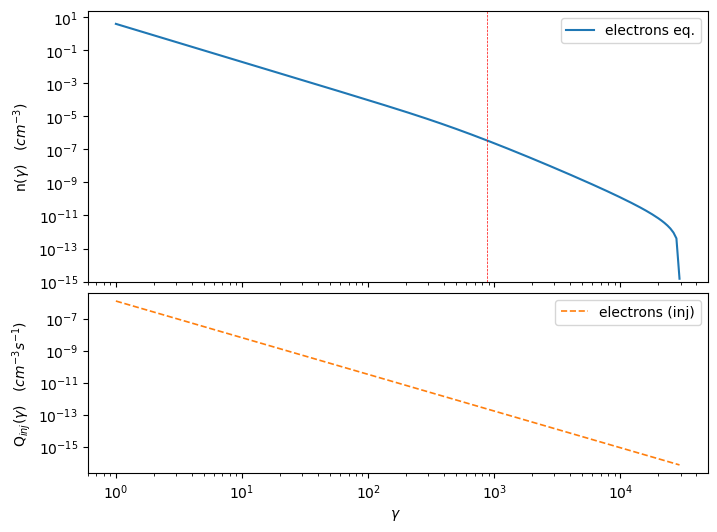

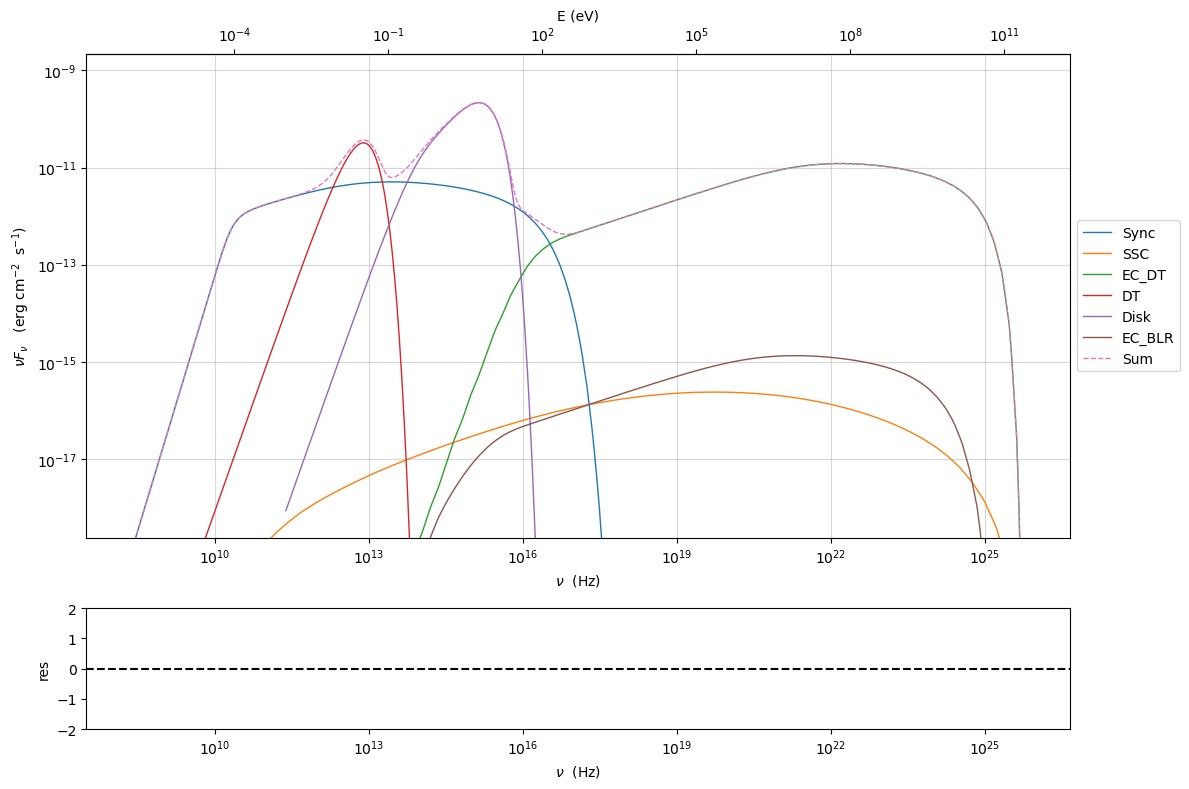

In [158]:
my_jet.eval()
p=my_jet.emitters_distribution.plot()
p.setlim(y_min=1E-15)
print('gamma eq. :',my_jet.emitters_distribution.gamma_cooling_eq)
my_jet.plot_model()

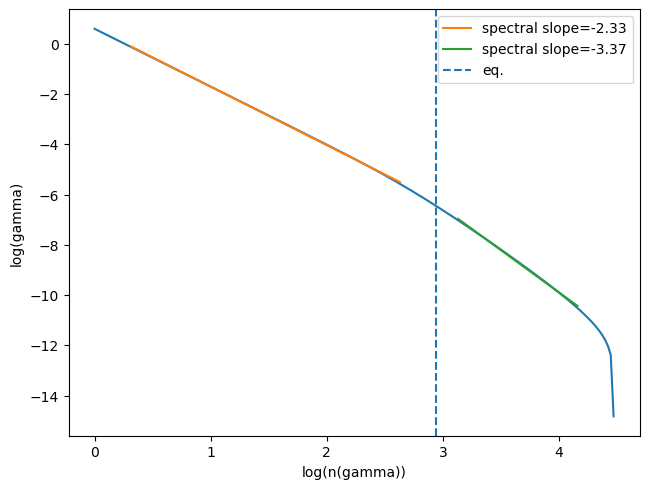

In [159]:
pl_fit(my_jet,x_eq=my_jet.emitters_distribution.gamma_cooling_eq)

In [160]:
from jetset.jet_model import Jet
from jetset.jet_emitters_factory import InjEmittersFactory

q_inj = InjEmittersFactory().create_inj_emitters('pl')
q_inj.parameters.gmax.val=3E4
my_jet=Jet(emitters_distribution=q_inj)
my_jet.parameters.p.val=2.2
my_jet.parameters.z_cosm.val=3.080000e-02
my_jet.parameters.B.val=.3
my_jet.parameters.p.val=2.3

my_jet.parameters.L_inj.val=1E40
my_jet.parameters.gmin.val=1
my_jet.parameters.gmax.val=3E4

my_jet.parameters.beam_obj.val=25


my_jet.make_conical_jet()
my_jet.parameters.R_H.val=1E18

adding par: R_H to  R
adding par: theta_open to  R
==> par R is depending on ['R_H', 'theta_open'] according to expr:   R =
np.tan(np.radians(theta_open))*R_H
setting R_H to 5.715026151380672e+16


gamma eq. : 2946.1518835079464


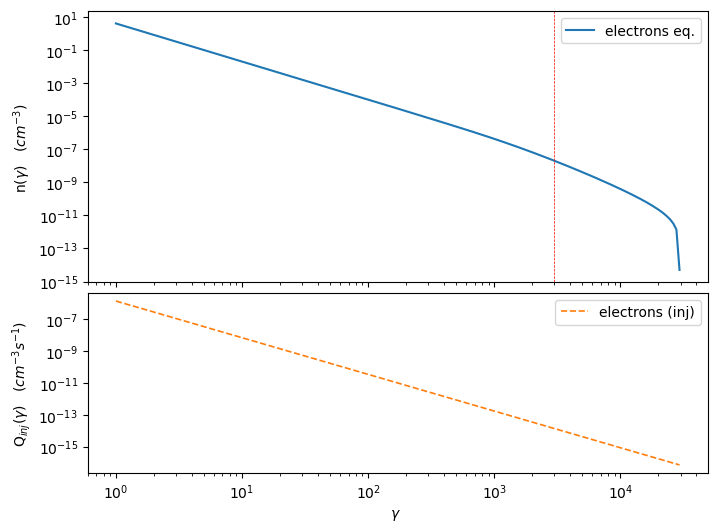

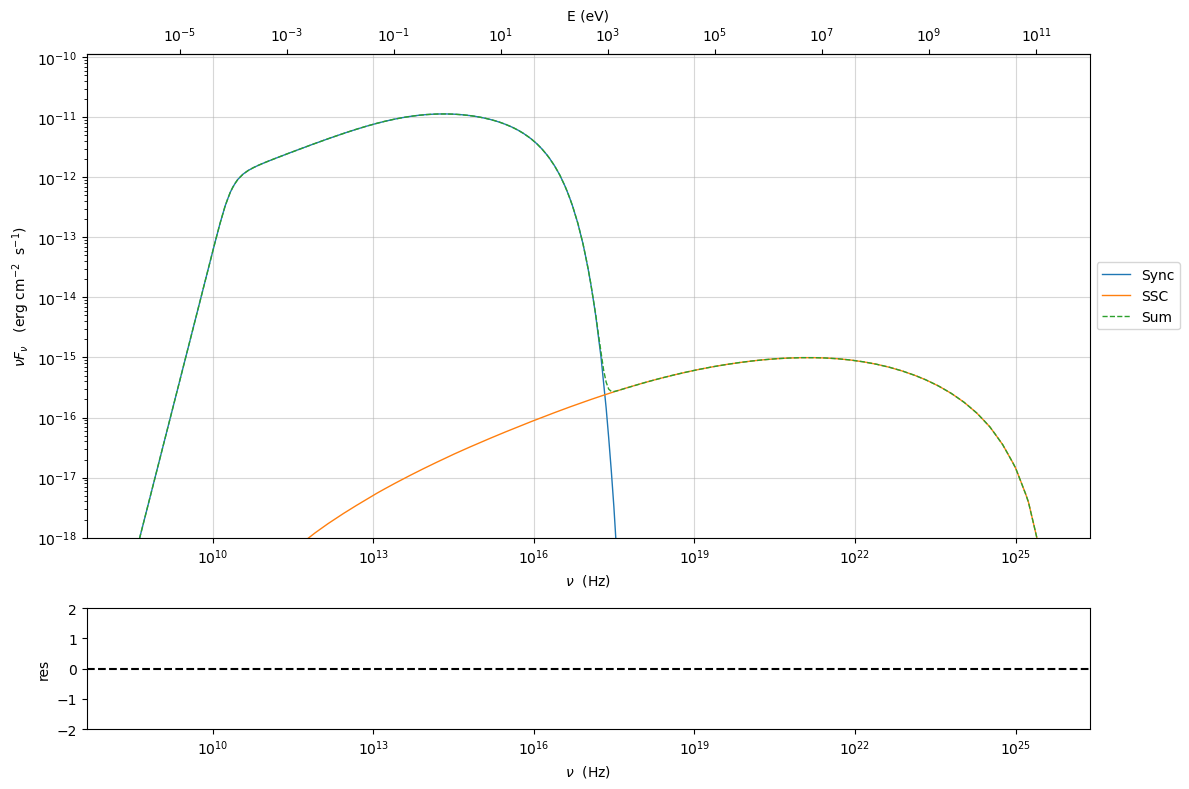

In [161]:
my_jet.eval()
p=my_jet.emitters_distribution.plot()
p.setlim(y_min=1E-15)
print('gamma eq. :',my_jet.emitters_distribution.gamma_cooling_eq)
my_jet.plot_model()

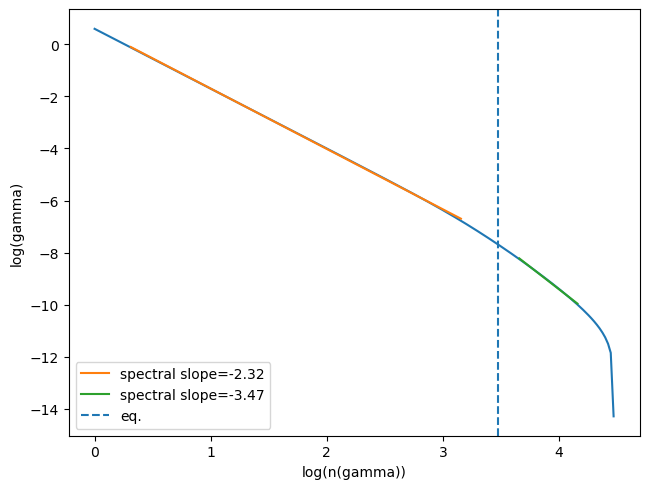

In [163]:
pl_fit(my_jet,x_eq=my_jet.emitters_distribution.gamma_cooling_eq)